In [1]:
%matplotlib inline
import sys, os, copy, json
import torch
import torch.nn as nn
import numpy as np
import torchvision
from torch.utils.data import DataLoader

sys.path.append('..')
from src.data.degredation import get_transforms
from src.models.resnet import resnet18  # CIFAR-native (3x3 stride-1 stem, 32x32)
from src.training.random_training import random_train, random_validation
from src.evaluation.inference import get_predictions_and_confidence
from src.visualization.overconfidence_plots import plot_confidence_distribution, plot_logit_distribution

import matplotlib.pyplot as plt
from custom.figure import mm, color

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams['font.family'] = 'DejaVu Sans'


In [2]:
dir = "cifar10-native-0919"
num_net = 10

figure_dir = os.path.join("..", "figures", dir)
save_dir = os.path.join("..", "results", dir)
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

criterion = nn.CrossEntropyLoss()
num_noise, input_shape, output_size = 50000, (3, 32, 32), 10  # native CIFAR-10 resolution, no resize
batch_size = 256

dataset_dir = "../dataset"
test_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Test: {len(test_dataset)}")


Test: 10000


c:\Users\vslab#1\Desktop\Chaewon\critical-period\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
def ckpt_path(tag, i):
    return os.path.join(save_dir, f"warmup_{tag}_{i}.pth")

def warmup_and_measure(tag, lr, epochs_noise=10, momentum=0.9, weight_decay=1e-4, seed_base=42, num_net=num_net, title=""):
    """CIFAR-native resnet18, native 32x32 input, noise warm-up at the given lr,
    then measure confidence + logit stats on real CIFAR-10 test set"""
    conf_all, logit_all = [], []

    for net_idx in range(num_net):
        torch.manual_seed(seed_base + net_idx)
        np.random.seed(seed_base + net_idx)

        model = resnet18(num_classes=output_size).to(device)

        if os.path.exists(ckpt_path(tag, net_idx)):
            model.load_state_dict(torch.load(ckpt_path(tag, net_idx), map_location=device))
            print(f"[{tag}] net {net_idx} loaded existing checkpoint, skipping warm-up")
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

            noise_loss, noise_acc = random_validation(
                model, criterion, input_shape, num_noise, batch_size, output_size, device=device)
            print(f"[{tag}] net {net_idx} warm-up epoch 0/{epochs_noise} (baseline) "
                  f"loss={noise_loss:.4f} acc={noise_acc:.4f}")

            for epoch in range(1, epochs_noise + 1):
                noise_loss, noise_acc = random_train(
                    model, optimizer, criterion, input_shape, num_noise, batch_size, output_size, device=device)
                print(f"[{tag}] net {net_idx} warm-up epoch {epoch}/{epochs_noise} "
                      f"loss={noise_loss:.4f} acc={noise_acc:.4f}")

            torch.save(model.state_dict(), ckpt_path(tag, net_idx))

        _, conf, _, _, logit = get_predictions_and_confidence(
            model, test_loader, device=device, return_logits=True)
        per_sample_range = logit.max(axis=1) - logit.min(axis=1)

        print(f"[{tag}] net {net_idx} confidence: mean={conf.mean():.4f} std={conf.std():.4f}  "
              f"(chance=1/{output_size}={1/output_size:.4f})")
        print(f"[{tag}] net {net_idx} logit (raw): min={logit.min():.2f} max={logit.max():.2f} "
              f"mean={logit.mean():.2f} std={logit.std():.2f}")
        print(f"[{tag}] net {net_idx} logit per-sample range (max-min across classes): "
              f"mean={per_sample_range.mean():.2f} std={per_sample_range.std():.2f}")

        conf_all.append(conf)
        logit_all.append(logit)

    conf_all = np.concatenate(conf_all)
    logit_all = np.concatenate(logit_all)
    chance = 1 / output_size

    plot_confidence_distribution(conf_all, color["sky"], title, chance_level=chance)
    plot_logit_distribution(logit_all, color["sky"], title)

    return conf_all, logit_all


In [4]:
epochs_noise_list = [0, 1, 2, 3, 4, 5, 7, 10]


[native_lr0.1_r0] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r0] net 0 confidence: mean=0.9990 std=0.0083  (chance=1/10=0.1000)
[native_lr0.1_r0] net 0 logit (raw): min=-47.00 max=68.99 mean=3.05 std=14.16
[native_lr0.1_r0] net 0 logit per-sample range (max-min across classes): mean=47.03 std=13.55
[native_lr0.1_r0] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r0] net 1 confidence: mean=0.9353 std=0.1116  (chance=1/10=0.1000)
[native_lr0.1_r0] net 1 logit (raw): min=-232.86 max=102.59 mean=-1.98 std=37.63
[native_lr0.1_r0] net 1 logit per-sample range (max-min across classes): mean=121.33 std=39.74
[native_lr0.1_r0] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r0] net 2 confidence: mean=0.9008 std=0.1323  (chance=1/10=0.1000)
[native_lr0.1_r0] net 2 logit (raw): min=-34.51 max=81.69 mean=2.14 std=16.33
[native_lr0.1_r0] net 2 logit per-sample range (max-min across classes): mean=46.79 std=12.91
[native_lr0.1_r0] net 3 loaded

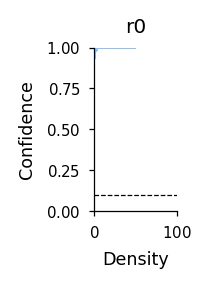

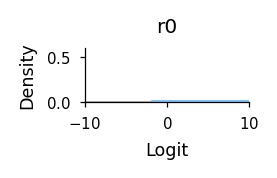

[native_lr0.1_r1] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r1] net 0 confidence: mean=0.6871 std=0.3693  (chance=1/10=0.1000)
[native_lr0.1_r1] net 0 logit (raw): min=-30.62 max=44.21 mean=-1.32 std=4.98
[native_lr0.1_r1] net 0 logit per-sample range (max-min across classes): mean=11.65 std=12.46
[native_lr0.1_r1] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r1] net 1 confidence: mean=0.3535 std=0.1919  (chance=1/10=0.1000)
[native_lr0.1_r1] net 1 logit (raw): min=-57.15 max=29.33 mean=-1.14 std=4.94
[native_lr0.1_r1] net 1 logit per-sample range (max-min across classes): mean=9.80 std=11.88
[native_lr0.1_r1] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r1] net 2 confidence: mean=0.2131 std=0.1428  (chance=1/10=0.1000)
[native_lr0.1_r1] net 2 logit (raw): min=-55.79 max=51.86 mean=0.32 std=3.61
[native_lr0.1_r1] net 2 logit per-sample range (max-min across classes): mean=4.93 std=9.42
[native_lr0.1_r1] net 3 loaded existin

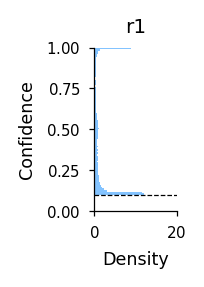

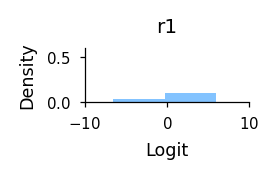

[native_lr0.1_r2] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r2] net 0 confidence: mean=0.4945 std=0.2803  (chance=1/10=0.1000)
[native_lr0.1_r2] net 0 logit (raw): min=-49.49 max=41.65 mean=0.43 std=5.64
[native_lr0.1_r2] net 0 logit per-sample range (max-min across classes): mean=13.66 std=14.27
[native_lr0.1_r2] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r2] net 1 confidence: mean=0.7481 std=0.3129  (chance=1/10=0.1000)
[native_lr0.1_r2] net 1 logit (raw): min=-71.95 max=69.88 mean=-0.09 std=8.09
[native_lr0.1_r2] net 1 logit per-sample range (max-min across classes): mean=21.31 std=20.23
[native_lr0.1_r2] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r2] net 2 confidence: mean=0.4254 std=0.2823  (chance=1/10=0.1000)
[native_lr0.1_r2] net 2 logit (raw): min=-25.25 max=24.21 mean=-0.61 std=3.11
[native_lr0.1_r2] net 2 logit per-sample range (max-min across classes): mean=5.87 std=7.29
[native_lr0.1_r2] net 3 loaded existi

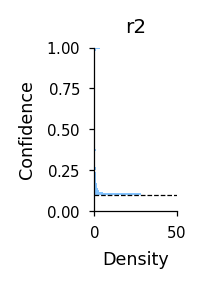

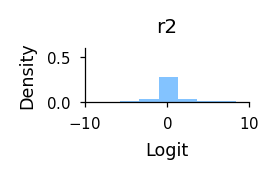

[native_lr0.1_r3] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r3] net 0 confidence: mean=0.6929 std=0.3618  (chance=1/10=0.1000)
[native_lr0.1_r3] net 0 logit (raw): min=-45.73 max=57.55 mean=0.21 std=5.90
[native_lr0.1_r3] net 0 logit per-sample range (max-min across classes): mean=15.51 std=16.45
[native_lr0.1_r3] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r3] net 1 confidence: mean=0.3337 std=0.2227  (chance=1/10=0.1000)
[native_lr0.1_r3] net 1 logit (raw): min=-9.59 max=11.27 mean=0.09 std=1.42
[native_lr0.1_r3] net 1 logit per-sample range (max-min across classes): mean=3.35 std=3.33
[native_lr0.1_r3] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r3] net 2 confidence: mean=0.1926 std=0.1691  (chance=1/10=0.1000)
[native_lr0.1_r3] net 2 logit (raw): min=-8.26 max=13.80 mean=0.10 std=0.65
[native_lr0.1_r3] net 2 logit per-sample range (max-min across classes): mean=1.18 std=2.00
[native_lr0.1_r3] net 3 loaded existing che

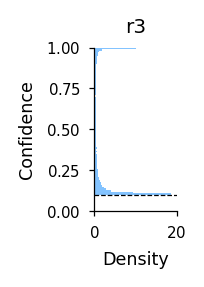

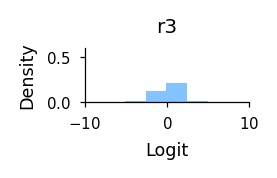

[native_lr0.1_r4] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r4] net 0 confidence: mean=0.4801 std=0.3134  (chance=1/10=0.1000)
[native_lr0.1_r4] net 0 logit (raw): min=-38.56 max=30.75 mean=0.52 std=4.45
[native_lr0.1_r4] net 0 logit per-sample range (max-min across classes): mean=10.61 std=11.27
[native_lr0.1_r4] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r4] net 1 confidence: mean=0.6163 std=0.3724  (chance=1/10=0.1000)
[native_lr0.1_r4] net 1 logit (raw): min=-44.45 max=49.13 mean=-0.85 std=5.84
[native_lr0.1_r4] net 1 logit per-sample range (max-min across classes): mean=12.36 std=14.36
[native_lr0.1_r4] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r4] net 2 confidence: mean=0.3213 std=0.2469  (chance=1/10=0.1000)
[native_lr0.1_r4] net 2 logit (raw): min=-17.37 max=37.60 mean=0.92 std=3.22
[native_lr0.1_r4] net 2 logit per-sample range (max-min across classes): mean=4.90 std=6.63
[native_lr0.1_r4] net 3 loaded existin

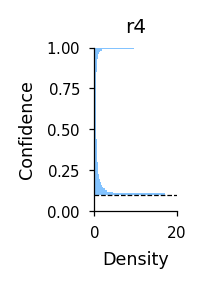

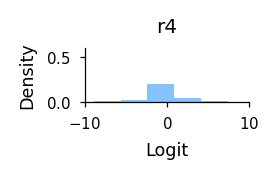

[native_lr0.1_r5] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r5] net 0 confidence: mean=0.3878 std=0.3170  (chance=1/10=0.1000)
[native_lr0.1_r5] net 0 logit (raw): min=-18.97 max=25.11 mean=0.28 std=2.26
[native_lr0.1_r5] net 0 logit per-sample range (max-min across classes): mean=4.79 std=6.33
[native_lr0.1_r5] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r5] net 1 confidence: mean=0.3569 std=0.2395  (chance=1/10=0.1000)
[native_lr0.1_r5] net 1 logit (raw): min=-4.20 max=16.62 mean=0.42 std=1.63
[native_lr0.1_r5] net 1 logit per-sample range (max-min across classes): mean=3.45 std=3.18
[native_lr0.1_r5] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r5] net 2 confidence: mean=0.5044 std=0.3214  (chance=1/10=0.1000)
[native_lr0.1_r5] net 2 logit (raw): min=-23.08 max=29.89 mean=0.27 std=2.70
[native_lr0.1_r5] net 2 logit per-sample range (max-min across classes): mean=6.74 std=7.21
[native_lr0.1_r5] net 3 loaded existing chec

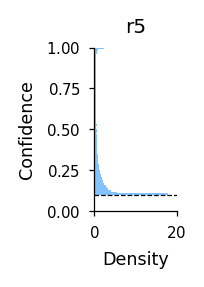

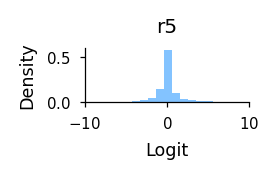

[native_lr0.1_r7] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r7] net 0 confidence: mean=0.2452 std=0.1476  (chance=1/10=0.1000)
[native_lr0.1_r7] net 0 logit (raw): min=-12.32 max=10.74 mean=0.19 std=1.68
[native_lr0.1_r7] net 0 logit per-sample range (max-min across classes): mean=3.49 std=3.78
[native_lr0.1_r7] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r7] net 1 confidence: mean=0.2531 std=0.1425  (chance=1/10=0.1000)
[native_lr0.1_r7] net 1 logit (raw): min=-8.68 max=7.78 mean=-0.12 std=1.31
[native_lr0.1_r7] net 1 logit per-sample range (max-min across classes): mean=2.84 std=2.95
[native_lr0.1_r7] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r7] net 2 confidence: mean=0.1978 std=0.1380  (chance=1/10=0.1000)
[native_lr0.1_r7] net 2 logit (raw): min=-3.93 max=7.34 mean=0.06 std=0.60
[native_lr0.1_r7] net 2 logit per-sample range (max-min across classes): mean=1.20 std=1.46
[native_lr0.1_r7] net 3 loaded existing checkp

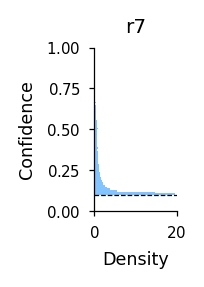

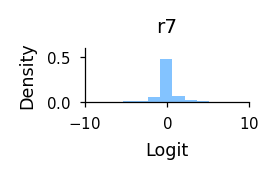

[native_lr0.1_r10] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r10] net 0 confidence: mean=0.2308 std=0.1303  (chance=1/10=0.1000)
[native_lr0.1_r10] net 0 logit (raw): min=-6.53 max=6.21 mean=-0.03 std=0.92
[native_lr0.1_r10] net 0 logit per-sample range (max-min across classes): mean=2.00 std=2.07
[native_lr0.1_r10] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r10] net 1 confidence: mean=0.3684 std=0.2280  (chance=1/10=0.1000)
[native_lr0.1_r10] net 1 logit (raw): min=-50.63 max=12.66 mean=-0.83 std=3.90
[native_lr0.1_r10] net 1 logit per-sample range (max-min across classes): mean=9.89 std=9.30
[native_lr0.1_r10] net 2 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r10] net 2 confidence: mean=0.1152 std=0.0223  (chance=1/10=0.1000)
[native_lr0.1_r10] net 2 logit (raw): min=-2.26 max=3.56 mean=0.05 std=0.19
[native_lr0.1_r10] net 2 logit per-sample range (max-min across classes): mean=0.31 std=0.46
[native_lr0.1_r10] net 3 loaded e

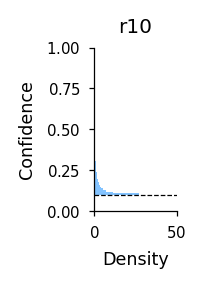

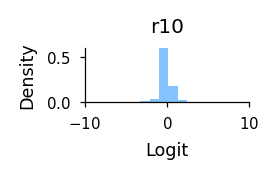

In [5]:

sweep_conf = {}
sweep_logit = {}
for r in epochs_noise_list:
    conf, logit = warmup_and_measure(f"native_lr0.1_r{r}", lr=0.1, epochs_noise=r, num_net=10, title=f"r{r}")
    sweep_conf[r] = conf
    sweep_logit[r] = logit


reload and statistics 

In [10]:
def load_sweep_results(epochs_noise_list, lr=0.1, num_net=num_net):
    sweep_conf = {}
    sweep_logit = {}
    for r in epochs_noise_list:
        tag = f"native_lr{lr}_r{r}"
        conf_all, logit_all = [], []
        for net_idx in range(num_net):
            path = ckpt_path(tag, net_idx)
            assert os.path.exists(path), f"no saved checkpoint for r={r}, net={net_idx}: {path}"
            model = resnet18(num_classes=output_size).to(device)
            model.load_state_dict(torch.load(path, map_location=device))
            _, conf, _, _, logit = get_predictions_and_confidence(
                model, test_loader, device=device, return_logits=True)
            conf_all.append(conf)
            logit_all.append(logit)
        sweep_conf[r] = np.concatenate(conf_all)
        sweep_logit[r] = np.concatenate(logit_all)
        print(f"r={r}: loaded {num_net} cached checkpoints (no training)")
    return sweep_conf, sweep_logit

sweep_conf, sweep_logit = load_sweep_results(epochs_noise_list)


r=0: loaded 10 cached checkpoints (no training)
r=1: loaded 10 cached checkpoints (no training)
r=2: loaded 10 cached checkpoints (no training)
r=3: loaded 10 cached checkpoints (no training)
r=4: loaded 10 cached checkpoints (no training)
r=5: loaded 10 cached checkpoints (no training)
r=7: loaded 10 cached checkpoints (no training)
r=10: loaded 10 cached checkpoints (no training)


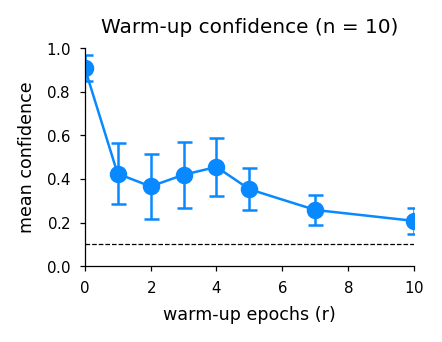

r    mean conf   95%CI     
0    0.9097      0.0593    
1    0.4241      0.1394    
2    0.3657      0.1478    
3    0.4191      0.1508    
4    0.4549      0.1316    
5    0.3527      0.0963    
7    0.2578      0.0684    
10   0.2077      0.0581    


In [11]:
from scipy import stats

def mean_ci95_per_net(values, num_net):
    """values is num_net chunks of equal length concatenated together (as
    warmup_and_measure builds conf_all) -- split back into per-net means,
    then take the 95% CI across nets (not across individual test images)."""
    per_net_means = np.array([chunk.mean() for chunk in np.array_split(values, num_net)])
    mean = per_net_means.mean()
    sem = per_net_means.std(ddof=1) / np.sqrt(num_net)
    ci95 = sem * stats.t.ppf(0.975, df=num_net - 1)
    return mean, ci95

sweep_means, sweep_cis = zip(*[mean_ci95_per_net(sweep_conf[r], num_net) for r in epochs_noise_list])
chance = 1 / output_size

plt.figure(figsize=(60 * mm, 40 * mm))
plt.errorbar(epochs_noise_list, sweep_means, yerr=sweep_cis, fmt='o-', color=color["sky"], capsize=3)
plt.axhline(y=chance, color='k', linestyle='--', linewidth=0.5)
plt.xlim(left=0)
plt.xlabel("warm-up epochs (r)")
plt.ylabel("mean confidence")
plt.title(f"Warm-up confidence (n = {num_net})")
plt.savefig(os.path.join(figure_dir, "confidence_vs_epochs_noise.svg"))
plt.show()

print(f"{'r':<5}{'mean conf':<12}{'95%CI':<10}")
for r, m, c in zip(epochs_noise_list, sweep_means, sweep_cis):
    print(f"{r:<5}{m:<12.4f}{c:<10.4f}")


In [12]:
from scipy.stats import ttest_ind_from_stats

def per_net_conf(values, num_net):
    return np.array([chunk.mean() for chunk in np.array_split(values, num_net)])

def per_net_logit_std(logit_array, num_net):
    return np.array([chunk.std() for chunk in np.array_split(logit_array, num_net, axis=0)])

baseline_r = 10
compare_rs = [r for r in epochs_noise_list if r != baseline_r]

baseline_conf = per_net_conf(sweep_conf[baseline_r], num_net)
baseline_logit_std = per_net_logit_std(sweep_logit[baseline_r], num_net)

print(f"baseline: r={baseline_r}  ({num_net} nets)")
print()
print(f"{'r':<5}{'conf t':<10}{'conf p':<12}{'logit_std t':<14}{'logit_std p':<12}")
for r in compare_rs:
    r_conf = per_net_conf(sweep_conf[r], num_net)
    r_logit_std = per_net_logit_std(sweep_logit[r], num_net)

    t_conf, p_conf = ttest_ind_from_stats(
        baseline_conf.mean(), baseline_conf.std(ddof=1), num_net,
        r_conf.mean(), r_conf.std(ddof=1), num_net)
    t_logit, p_logit = ttest_ind_from_stats(
        baseline_logit_std.mean(), baseline_logit_std.std(ddof=1), num_net,
        r_logit_std.mean(), r_logit_std.std(ddof=1), num_net)

    print(f"{r:<5}{t_conf:<10.3f}{p_conf:<12.2e}{t_logit:<14.3f}{p_logit:<12.2e}")


baseline: r=10  (10 nets)

r    t         p           
0    -19.129   2.07e-13    
1    -3.240    4.54e-03    
2    -2.250    3.72e-02    
3    -2.958    8.42e-03    
4    -3.889    1.08e-03    
5    -2.917    9.19e-03    
7    -1.264    2.23e-01    
